# Stent skeletonisation — interactive pipeline

In [ ]:
import numpy as np
import trimesh
import os
from pathlib import Path

from stentfit import (
    #  2D skeletonisation pipeline 
    sample_stent_points,
    detect_crowns,
    skeletonize_crowns_2d,
    save_crown_2d_checkpoint,
    # resume + manual 2D edits 
    load_crown_2d_checkpoint,
    edit_crowns_2d_interactive,
    assemble_2d_skeleton,
    # wrap to 3D, splines, exports, 2D/3D views 
    wrap_skeleton_to_3d,
    fit_skeleton_splines,
    save_stent_features_and_views,
    plot_skeleton_splines_2d,
    plot_skeleton_splines_trimesh,
    # 1D beam meshing
    mesh_skeleton_beams,
)

REPO_ROOT = Path('../..').resolve() / 'stentFIT'
print(f"Repository root: {REPO_ROOT}")

In [20]:
STENT_NAME = 'stent03'
STENT_NAME = '2crownCrimpedXienceStent'
STENT_NAME = '16crownCrimpedXienceStent+extremaSupports'

STENT_STL_FILE = os.path.join(REPO_ROOT, 'data', 'stent_designs', f'{STENT_NAME}.stl')
# sampling / display 
N_POINTS        = None        # None -> auto-decide the initial count from the stent
                              # size ratio (Step 1); set an int to force a count
MAX_DISPLAY     = 500_000      # max points drawn in any HTML view (display only);
                              # set to None to show ALL points (no downsampling)
RANDOM_SEED     = 0
REMOVE_SUPPORTS = (STENT_NAME == '16crownCrimpedXienceStent+extremaSupports')

# Step-6 wrap memory guard (ONLY affects Step 6's mid-surface radius estimate;
# Steps 1-5.5 always use the full-density sampling). None = use the full cloud.
# Big stents (~16M pts) OOM-crash the wrap, so downsample the wrap surface there.
WRAP_MAX_SURF = 2_000_000 if STENT_NAME == '16crownCrimpedXienceStent+extremaSupports' else None

# 2D skeletonisation (per crown)
AUTO_TUNE        = True       # tune pixels_per_strut / dilate_px per crown
PIXELS_PER_STRUT = 10
DILATE_PX        = 3
PAD_FRACTION     = 0.20
TUNE_TIME_LIMIT  = 120       # seconds per crown when AUTO_TUNE
QUALITY_GAMMA    = 2.0
SEAM_TOL_FRAC    = 0.01
SEAM_Z_TOL_FRAC  = 3.0
CROWN_HALO_FRAC  = 0.4
PRUNE_TIP_FRAC   = 0

L_EL = 0.1
YOUNGS_MODULUS = 2.0e5
POISSON_RATIO = 0.3
DENSITY = 0.0
BEAM_CLASS_LABEL = 'Beam3rHerm2Line3'

print(f"Config ready for '{STENT_NAME}'")
print(f"  STL    : {STENT_STL_FILE}")

Config ready for '16crownCrimpedXienceStent+extremaSupports'
  STL    : /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/data/stent_designs/16crownCrimpedXienceStent+extremaSupports.stl


## Wrapper A — 2D skeletonisation pipeline 

`run_skeletonization_2d()` runs the whole 2D half of the pipeline — sample the STL,
detect crowns, skeletonise each crown in 2D, and save the per-crown checkpoint
(`crown_2d.pkl`). It returns a `state` dict that carries everything the later
wrappers need. Inspect the HTML views it writes into `notebook_outputs/<STENT_NAME>/`
before moving on.

In [21]:
def run_skeletonization_2d(repo_root:str,
                           stl_file:str, 
                           stent_name:str, 
                           n_points:int = None, 
                           max_display:int = 500_000,
                           remove_supports:bool = False,
                           random_seed:int = 0,
                           auto_tune:bool = True,
                           pixels_per_strut:int = 10,
                           dilate_px:int = 3,
                           pad_fraction:float = 0.20,
                           tune_time_limit:int = 120,
                           quality_gamma:float = 2.0,
                           seam_tol_frac:float = 0.01,
                           crown_halo_frac:float = 0.4,
                           ):
    """sample -> detect crowns -> 2D skeletonise -> checkpoint"""


    # Check the STL file exists; if not, there is nothing to skeletonise.
    if not os.path.isfile(stl_file):
        raise FileNotFoundError(
            f"No STL file for stent '{stent_name}' at: {stl_file}")

    # Resolve the output folder. If a non-empty one is already there, ask whether to
    # reuse it as-is, overwrite (wipe) it, or branch off into a new versioned folder
    # (<name>_v02, _v03, ...).
    output_dir = os.path.join(repo_root, 'examples', 'notebook_outputs', stent_name)
    if os.path.isdir(output_dir) and os.listdir(output_dir):
        choice = input(
            f"Output folder already exists and is not empty:\n  {output_dir}\n"
            f"  [e] use it as-is   [o] overwrite (wipe it first)   "
            f"[n] make a new versioned folder\nChoose [e/o/n]: ").strip().lower()
        if choice.startswith('o'):
            import shutil
            shutil.rmtree(output_dir)
            print(f"[output] wiped and reusing {output_dir}")
        elif choice.startswith('n'):
            parent, base = os.path.split(output_dir.rstrip('/\\'))
            v = 2
            while os.path.isdir(os.path.join(parent, f"{base}_v{v:02d}")):
                v += 1
            output_dir = os.path.join(parent, f"{base}_v{v:02d}")
            print(f"[output] using a new folder: {output_dir}")
        else:
            print(f"[output] reusing existing folder as-is: {output_dir}")
            state = load_crown_2d_checkpoint(output_dir)
            state['output_dir'] = output_dir
            return state
    os.makedirs(output_dir, exist_ok=True)

    mesh = trimesh.load(stl_file)
    print(f"Loaded mesh: {stl_file}")

    sampled = sample_stent_points(
        mesh, stent_name, output_dir, n_points=n_points, max_display=max_display,
        remove_supports=remove_supports, random_seed=random_seed)
    stent_df       = sampled['stent_df']
    stent_features = sampled['stent_features']
    centerline_dir = sampled['stent_centerline_direction']

    crowns = detect_crowns(stent_df, stent_features, stent_name, output_dir,
                           max_display=max_display)
    stent_df       = crowns['stent_df']
    crown_edges    = crowns['crown_edges']
    conn_radius_3d = crowns['conn_radius_3d']

    skel = skeletonize_crowns_2d(
        stent_df, stent_features, crown_edges, conn_radius_3d, output_dir,
        auto_tune=auto_tune, pixels_per_strut=pixels_per_strut, dilate_px=dilate_px,
        pad_fraction=pad_fraction, tune_time_limit=tune_time_limit,
        quality_gamma=quality_gamma, seam_tol_frac=seam_tol_frac,
        crown_halo_frac=crown_halo_frac)
    crown_2d    = skel['crown_2d']
    crown_order = skel['crown_order']

    r_mid           = stent_features['r_mid']
    strut_thickness = stent_features['strut_thickness']
    circumference   = 2 * np.pi * r_mid

    save_crown_2d_checkpoint(crown_2d, stent_features, centerline_dir, r_mid,
                             strut_thickness, circumference, crown_edges, output_dir)

    return {
        'crown_2d'                  : crown_2d,
        'crown_order'               : crown_order,
        'stent_df'                  : stent_df,
        'stent_features'            : stent_features,
        'stent_centerline_direction': centerline_dir,
        'r_mid'                     : r_mid,
        'strut_thickness'           : strut_thickness,
        'circumference'             : circumference,
        'crown_edges'               : crown_edges,
        'output_dir'                : output_dir
    }

## Wrapper B — resume + manual 2D edits

`resume_and_edit_crowns(OUTPUT_DIR, state)` optionally fixes any defect the detector
missed (interactive: name two anchor indices per fix), then assembles the full 2D
skeleton. In a normal run it uses the in-memory `state`; **after a kernel restart**,
run the config + imports cells and then this cell — with `state` undefined it reloads
`crown_2d.pkl` + `crown_points.csv` from disk automatically.

In [22]:
def resume_and_edit_crowns(output_dir:str, 
                           state:dict=None,
                           interactive:bool=True):
    """Resume + Step 5.5: (optionally reload the checkpoint) -> interactive 2D edits
    -> assemble the full 2D skeleton.

    Pass the `state` from run_skeletonization_2d() in a normal run; pass state=None
    (e.g. after a kernel restart, or when resuming straight from an output folder) to
    reload crown_2d.pkl + crown_points.csv from disk. Set interactive=False to skip the
    manual-edit prompts (useful for scripted / non-interactive runs). Returns the state
    updated with the assembled 2D skeleton (skel_arc/skel_z/...)."""
    if state is None:
        state = load_crown_2d_checkpoint(output_dir)
    else:
        print("[resume] using in-memory state (normal run).")

    if interactive:
        state['crown_2d'] = edit_crowns_2d_interactive(
            state['crown_2d'], state['stent_features'], state['stent_centerline_direction'],
            state['r_mid'], state['strut_thickness'], state['circumference'],
            state['crown_edges'], output_dir)
    else:
        print("[resume] interactive=False -> skipping manual 2D edits.")

    state.update(assemble_2d_skeleton(state['crown_2d']))
    state['surf_df'] = state['stent_df']
    return state

## Wrapper C — wrap to 3D, splines, exports, views

`finalize_skeleton(state)` wraps the (edited) 2D skeleton onto the local mid-surface
and runs the graph cleanup, fits a B-spline per curve, writes the final exports
(`skeleton_points.csv`, `skeleton_splines.json`, `stent_features.json`, and the HTML
views), and renders the unrolled-2D + trimesh-3D spline views.

In [23]:
def finalize_skeleton(state:dict,
                      output_dir:str,
                      stent_name:str,
                      wrap_max_surf:int = None,
                      seam_tol_frac:float = 0.01,
                      seam_z_tol_frac:float = 3,
                      prune_tip_frac:float = 0,
                      max_display:int = 500_000,
                      random_seed:int = 0):
    """wrap the 2D skeleton to 3D, fit splines,
    write the final exports, and render the unrolled-2D + trimesh-3D views."""
    

    skeleton_df = wrap_skeleton_to_3d(
        state['skel_arc'], state['skel_z'], state['skel_px'], state['pixel_size'],
        state['surf_df'], state['r_mid'], state['circumference'],
        state['strut_thickness'], output_dir, stent_name, wrap_max_surf=wrap_max_surf,
        seam_tol_frac=seam_tol_frac, seam_z_tol_frac=seam_z_tol_frac, prune_tip_frac=prune_tip_frac,
        max_display=max_display, random_seed=random_seed)

    fitted = fit_skeleton_splines(skeleton_df, output_dir)
    skeleton_curves  = fitted['curves']
    skeleton_splines = fitted['splines']

    save_stent_features_and_views(
        skeleton_df, state['stent_df'], state['stent_features'],
        state['stent_centerline_direction'], state['crown_edges'], output_dir,
        stent_name, max_display=max_display)

    plot_skeleton_splines_2d(
        skeleton_curves, skeleton_splines, state['stent_df'], state['r_mid'],
        state['circumference'], state['crown_edges'], state.get('crown_order'),
        output_dir, stent_name)
    plot_skeleton_splines_trimesh(skeleton_splines, output_dir)

    state['skeleton_df']      = skeleton_df
    state['skeleton_curves']  = skeleton_curves
    state['skeleton_splines'] = skeleton_splines
    return state

## One call — `stent_pipeline` (combines all three wrappers)

In [24]:
def stent_pipeline( mesh_beams:bool,
                    repo_root:str,
                    stent_name:str,
                    n_points:int = None, 
                    max_display:int = 500_000,
                    remove_supports:bool = False,
                    random_seed:int = 0,
                    auto_tune:bool = True,
                    pixels_per_strut:int = 10,
                    dilate_px:int = 3,
                    pad_fraction:float = 0.20,
                    tune_time_limit:int = 120,
                    quality_gamma:float = 2.0,
                    seam_tol_frac:float = 0.01,
                    crown_halo_frac:float = 0.4, 
                    
                    wrap_max_surf:int = None,
                    seam_z_tol_frac:float = 3,
                    prune_tip_frac:float = 0,

                    l_el:float=0.1,
                    youngs_modulus:float=2.0e5,
                    poisson_ratio:float=0.3,
                    density:float=0.0,
                    beam_class_label:str='Beam3rHerm2Line3', 
                    ):
    

    stl_file = os.path.join(repo_root, 'data', 'stent_designs', f'{stent_name}.stl')

    state = run_skeletonization_2d( repo_root=repo_root,
                                    stl_file=stl_file, 
                                    stent_name=stent_name, 
                                    n_points=n_points,
                                    max_display=max_display,
                                    remove_supports=remove_supports,
                                    random_seed=random_seed,
                                    auto_tune=auto_tune,
                                    pixels_per_strut=pixels_per_strut,
                                    dilate_px=dilate_px,
                                    pad_fraction=pad_fraction,
                                    tune_time_limit=tune_time_limit,
                                    quality_gamma=quality_gamma,
                                    seam_tol_frac=seam_tol_frac,
                                    crown_halo_frac=crown_halo_frac)
    output_dir = state['output_dir']

    # Normal run: pass the in-memory `state`. After a kernel restart, `state` is undefined
    # and this reloads the Step-5.4 checkpoint from disk automatically.
    state = resume_and_edit_crowns(output_dir, globals().get('state'))
    

    state = finalize_skeleton(  state=state,
                                output_dir=output_dir,
                                stent_name=stent_name,
                                wrap_max_surf=wrap_max_surf,
                                seam_tol_frac=seam_tol_frac,
                                seam_z_tol_frac=seam_z_tol_frac,
                                prune_tip_frac=prune_tip_frac,
                                max_display=max_display,
                                random_seed=random_seed)
    
    if mesh_beams:
        beam_mesh = mesh_skeleton_beams(output_dir=output_dir,
                                        l_el=l_el,
                                        youngs_modulus=youngs_modulus,
                                        poisson_ratio=poisson_ratio,
                                        density=density,
                                        beam_class_label=beam_class_label)


    print(f"[pipeline] done -> {output_dir}") 

[output] reusing existing folder as-is: /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/examples/notebook_outputs/16crownCrimpedXienceStent+extremaSupports
[resume] loading point cloud from /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/examples/notebook_outputs/16crownCrimpedXienceStent+extremaSupports/crown_points.csv ...
[resume] restored 14 per-crown 2D skeletons + 16,172,128 surface points. Ready for the manual-edit step.
[resume] loading point cloud from /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/examples/notebook_outputs/16crownCrimpedXienceStent+extremaSupports/crown_points.csv ...
[resume] restored 14 per-crown 2D skeletons + 16,172,128 surface points. Ready for the manual-edit step.

Assembled 2D skeleton: 103,683 points | pixel_size median = 0.00273
[wrap] downsampled surface for the wrap: 16,172,128 -> 2,000,000 pts (wrap_max_surf)
[seam-merge] rails: 66 low / 120 high -> 46 pair(s) merged to midpoint; total nodes 103683 -> 103637 (band=0

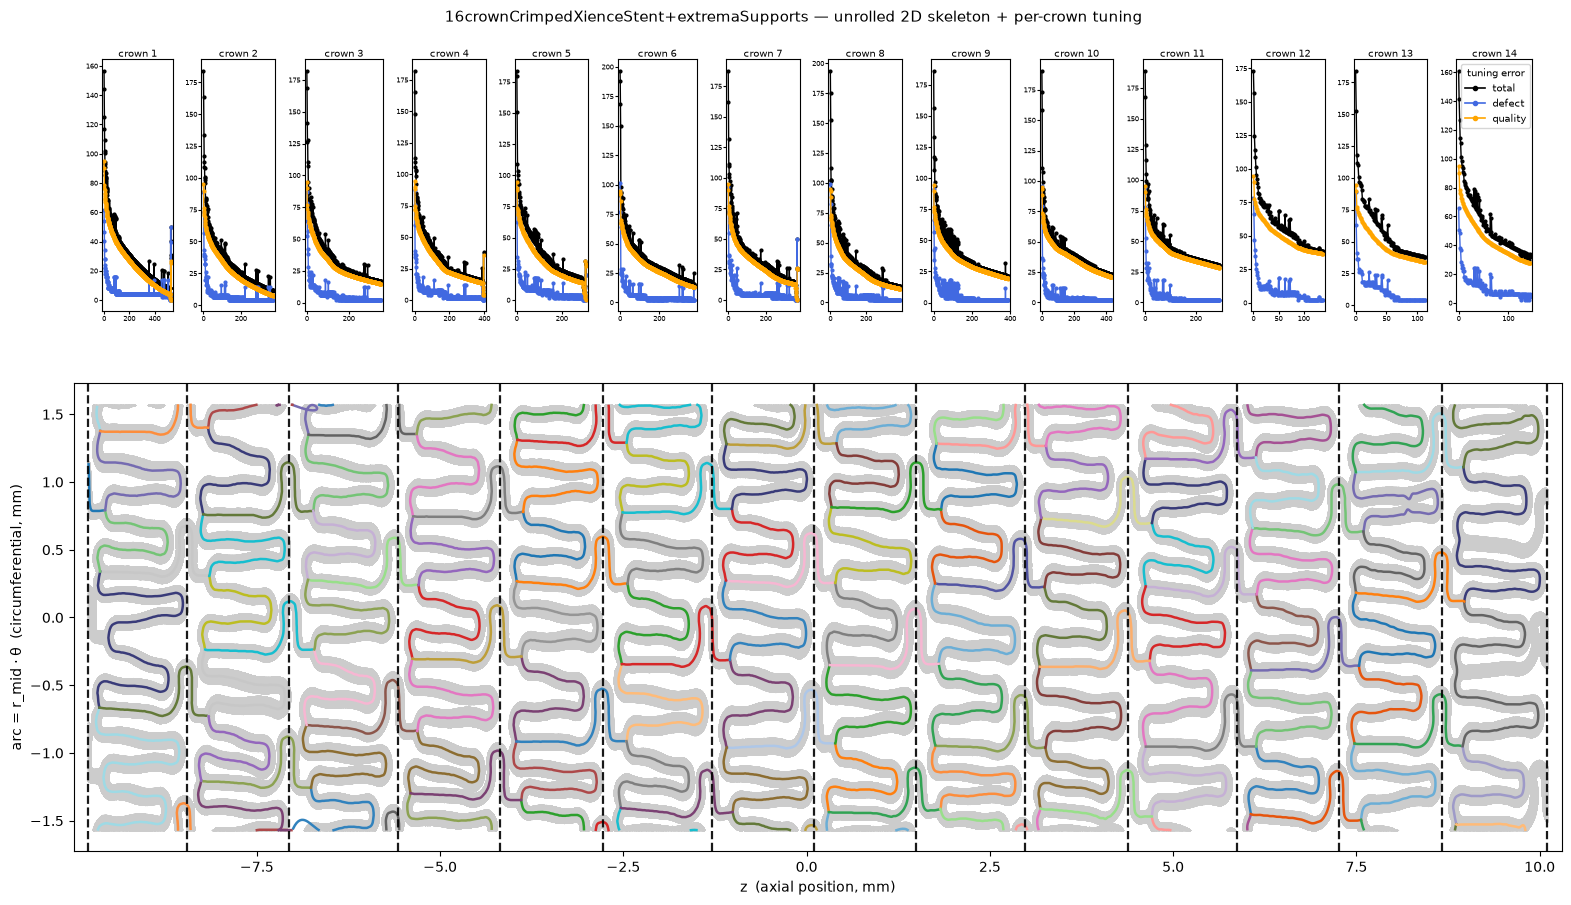

[saved] /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/examples/notebook_outputs/16crownCrimpedXienceStent+extremaSupports/skeleton_splines_2d.png  (123 curves, 15 crown boundaries, 14/14 crown tuning plots)
[saved] /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/examples/notebook_outputs/16crownCrimpedXienceStent+extremaSupports/skeleton_splines_2d.html
[saved] /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/examples/notebook_outputs/16crownCrimpedXienceStent+extremaSupports/skeleton_splines_trimesh.html
[saved] /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/examples/notebook_outputs/16crownCrimpedXienceStent+extremaSupports/skeleton_splines.glb  (123 spline curves)
[folder] read stent_features.json from /Users/vural/Desktop/RWTH - SiSc/Projects/Github/stentFIT/examples/notebook_outputs/16crownCrimpedXienceStent+extremaSupports
[folder] strut_thickness = 0.2052 mm

Meshed 123/123 curves (0 skipped) into a 1D beam mesh:
  5,745 nodes, 2,811 Bea

In [ ]:
state = stent_pipeline( mesh_beams=True,
                        repo_root=REPO_ROOT,
                        stent_name=STENT_NAME,
                        n_points=N_POINTS,
                        max_display=MAX_DISPLAY,
                        remove_supports=REMOVE_SUPPORTS,
                        random_seed=RANDOM_SEED,
                        auto_tune=AUTO_TUNE,
                        pixels_per_strut=PIXELS_PER_STRUT,
                        dilate_px=DILATE_PX,
                        pad_fraction=PAD_FRACTION,
                        tune_time_limit=TUNE_TIME_LIMIT,
                        quality_gamma=QUALITY_GAMMA,
                        seam_tol_frac=SEAM_TOL_FRAC,
                        crown_halo_frac=CROWN_HALO_FRAC,
                        wrap_max_surf=WRAP_MAX_SURF,
                        seam_z_tol_frac=SEAM_Z_TOL_FRAC,
                        prune_tip_frac=PRUNE_TIP_FRAC,
                        l_el=L_EL,
                        youngs_modulus=YOUNGS_MODULUS, 
                        poisson_ratio=POISSON_RATIO,
                        density=DENSITY,
                        beam_class_label=BEAM_CLASS_LABEL)